In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Tools.data_utils import SimulationData, lorenz_stochastic, generate_input_filename
from Tools.mathematical_tools import mutual_information, false_nearest_neighbors, denormalize_columns
from Tools.analysis_tools import reconstruct_signal_from_embedding

In [3]:
tau = 3
embedding_dim = 30
r = 20
alpha = 0
beta = 0
simulation_name= generate_input_filename(tau, embedding_dim, r, alpha, beta)    
# Carica i dati di simulazione
simulation = SimulationData.load_from_params(
    tau=tau, embedding_dim=embedding_dim, r=r, alpha=alpha, beta=beta, input_path="Simulation data"
)

z1 = simulation.trajectory[:, 0]
z2 = simulation.trajectory[:, 1]
z3 = simulation.trajectory[:, 2]

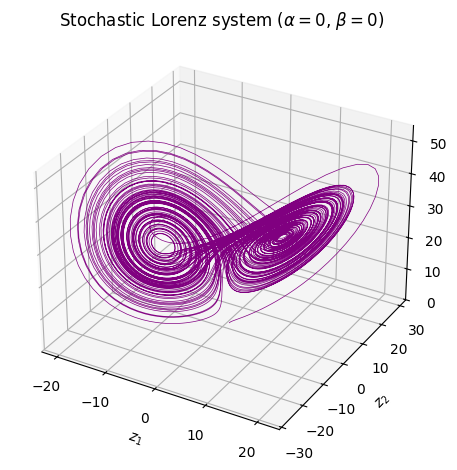

In [4]:
# Grafico delle traiettorie 
fig = plt.figure(figsize=(12, 6))
# Primo subplot
ax = fig.add_subplot(121, projection="3d")
ax.plot(simulation.trajectory[:, 0], simulation.trajectory[:, 1], simulation.trajectory[:, 2], color='purple', lw=0.5)
ax.set_title(rf"Stochastic Lorenz system ($\alpha={alpha}$, $\beta={beta}$)")
ax.set_xlabel(f"$z_1$")
ax.set_ylabel(f"$z_2$")
ax.set_zlabel(f"$z_3$")
plt.show()


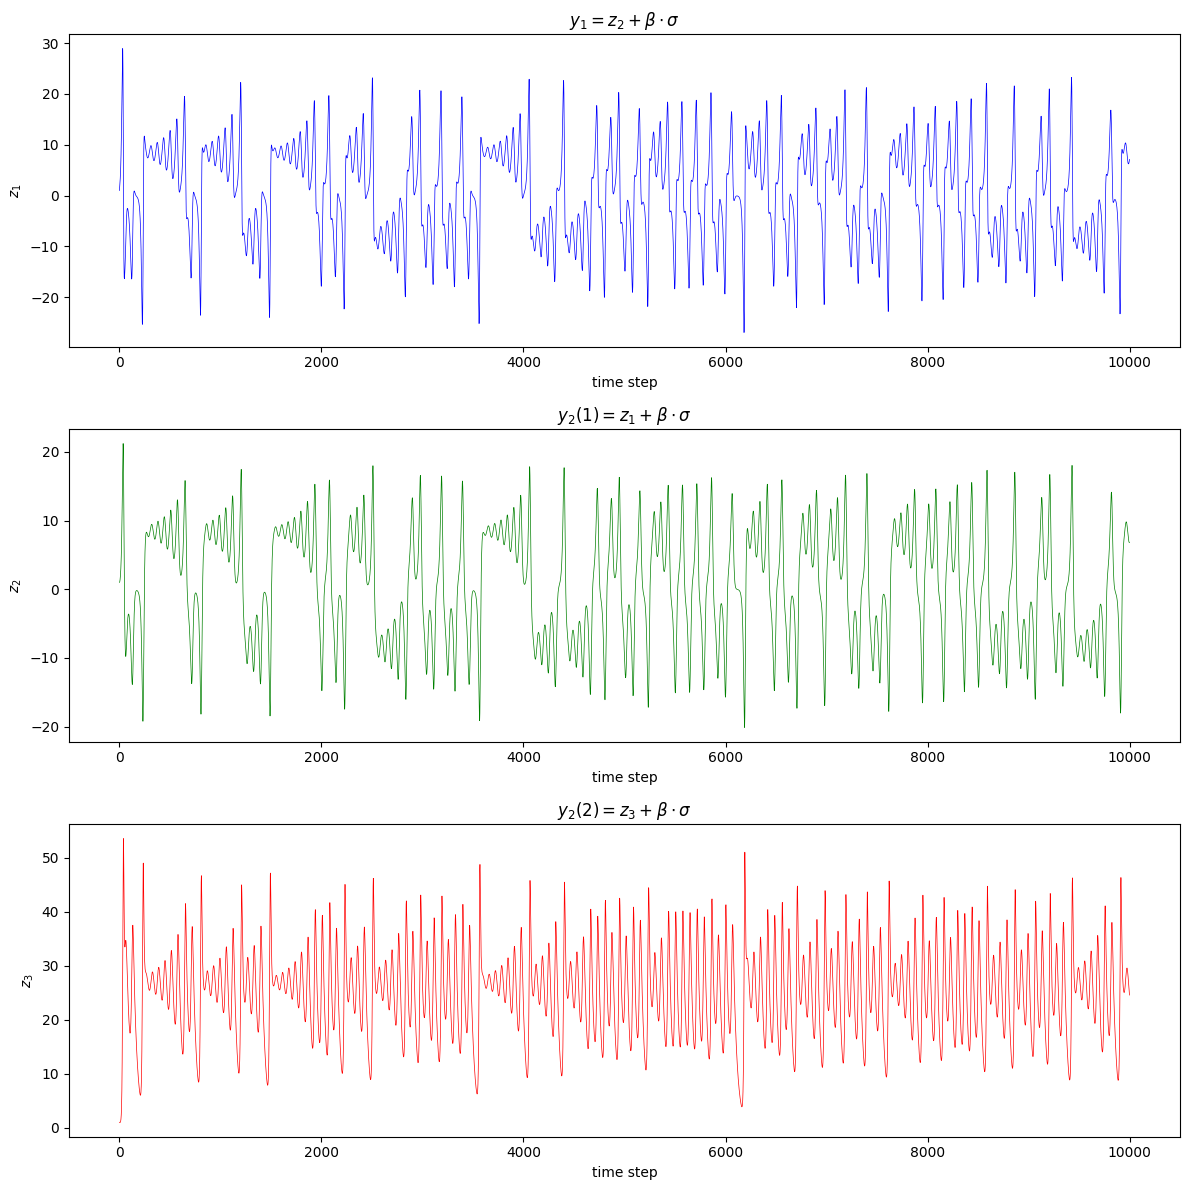

In [22]:
# Grafico delle serie temporali
fig = plt.figure(figsize=(12, 12))
# Primo subplot
ax1 = fig.add_subplot(311)
ax1.plot(simulation.y1, color='blue', lw=0.5)
ax1.set_title(r"$y_1 = z_2 + \beta \cdot \sigma$")
ax1.set_xlabel("time step")
ax1.set_ylabel("$z_1$")

ax2 = fig.add_subplot(312)
ax2.plot(simulation.y2[:,0], color='green', lw=0.5)
ax2.set_title(r"$y_2(1) = z_1 + \beta \cdot \sigma$")
ax2.set_xlabel("time step")
ax2.set_ylabel("$z_2$")

ax3 = fig.add_subplot(313)
ax3.plot(simulation.y2[:,1], color='red', lw=0.5)
ax3.set_title(r"$y_2(2) = z_3 + \beta \cdot \sigma$")
ax3.set_xlabel("time step")
ax3.set_ylabel("$z_3$")

plt.tight_layout()
plt.show()

In [6]:
# Inizializzazione della lista per salvare i risultati
range_f = 100  # Numero massimo di ritardi da analizzare
n_bins = 25   # Numero di bin per la discretizzazione
datDelayInformation_1 = []  
datDelayInformation_2 = []
datDelayInformation_3 = []

# Calcolo della mutual information per ogni ritardo
for delay in range(1, range_f):
    I = mutual_information(z1, delay, n_bins)  # mutual_information calcolata per z1
    datDelayInformation_1.append(I)

# Calcolo della mutual information per ogni ritardo
for delay in range(1, range_f):
    I = mutual_information(z2, delay, n_bins)  # mutual_information calcolata per z2
    datDelayInformation_2.append(I)

# Calcolo della mutual information per ogni ritardo
for delay in range(1, range_f):
    I = mutual_information(z3, delay, n_bins)  # mutual_information calcolata per z3
    datDelayInformation_3.append(I)

0.999899989999
0.999899989999
0.9997999799979997
0.9998999799959991
0.9998999799959991
0.9997999599919984
0.9998999699909972
0.9998999699909973
0.9997999399819947
0.9998999599839935
0.9998999599839936
0.9997999199679871
0.9998999499749875
0.9998999499749874
0.999799899949975
0.9998999399639783
0.9998999399639784
0.9997998799279568
0.9998999299509655
0.9998999299509657
0.9997998599019313
0.9998999199359488
0.9998999199359488
0.9997998398718976
0.999899909918927
0.9998999099189271
0.999799819837854
0.9998998998999
0.9998998998998999
0.9997997997997998
0.9998998898788667
0.9998998898788668
0.9997997797577335
0.999899879855827
0.999899879855827
0.9997997597116539
0.99989986983078
0.9998998698307802
0.9997997396615599
0.9998998598037252
0.9998998598037252
0.9997997196074504
0.9998998497746621
0.9998998497746621
0.999799699549324
0.9998998397435898
0.9998998397435896
0.9997996794871795
0.9998998297105078
0.999899829710508
0.9997996594210157
0.9998998196754157
0.9998998196754157
0.99979963935

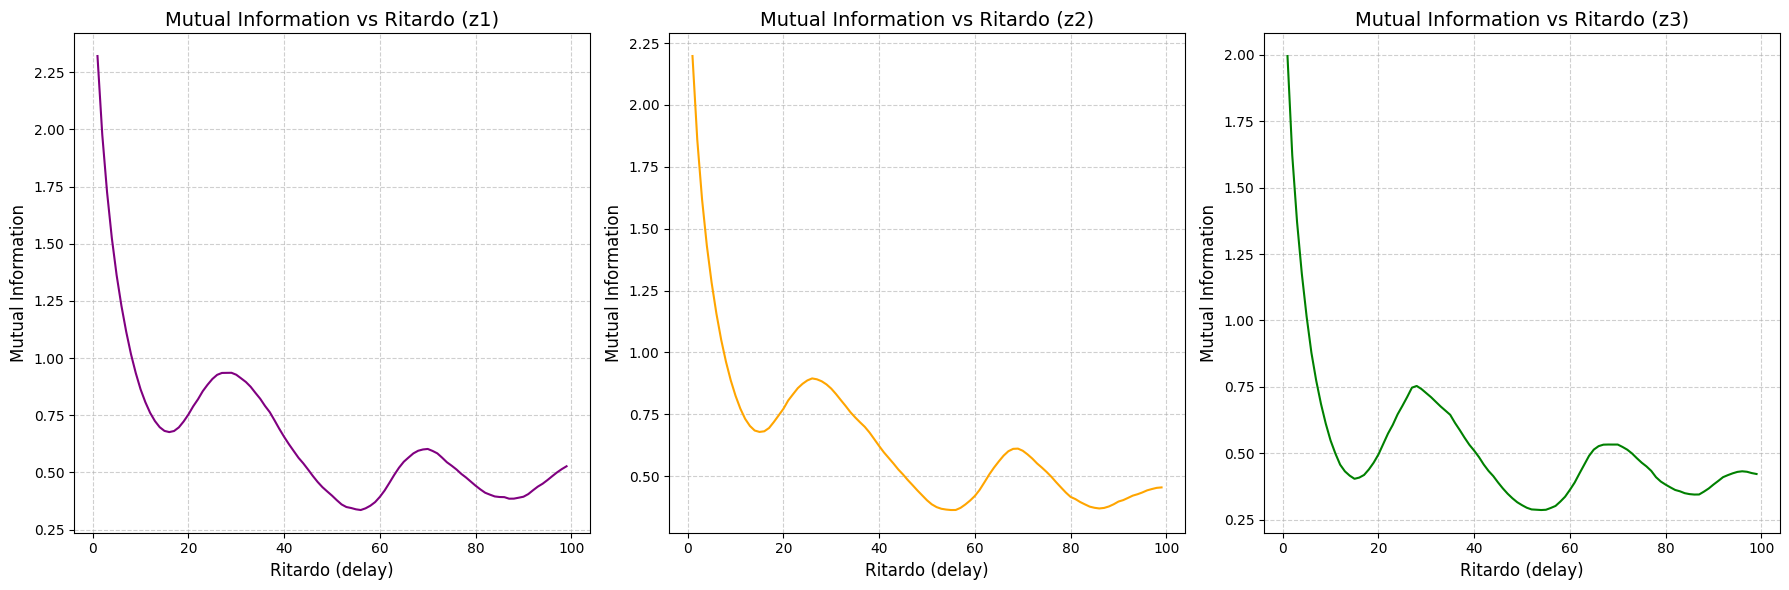

3.2188758248682006


In [7]:
# Grafico dei risultati
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot for datDelayInformation_1
axs[0].plot(range(1, range_f), datDelayInformation_1, color='purple')
axs[0].set_xlabel('Ritardo (delay)', fontsize=12)
axs[0].set_ylabel('Mutual Information', fontsize=12)
axs[0].set_title('Mutual Information vs Ritardo (z1)', fontsize=14)
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot for datDelayInformation_2
axs[1].plot(range(1, range_f), datDelayInformation_2, color='orange')
axs[1].set_xlabel('Ritardo (delay)', fontsize=12)
axs[1].set_ylabel('Mutual Information', fontsize=12)
axs[1].set_title('Mutual Information vs Ritardo (z2)', fontsize=14)
axs[1].grid(True, linestyle='--', alpha=0.6)

# Plot for datDelayInformation_3
axs[2].plot(range(1, range_f), datDelayInformation_3, color='green')
axs[2].set_xlabel('Ritardo (delay)', fontsize=12)
axs[2].set_ylabel('Mutual Information', fontsize=12)
axs[2].set_title('Mutual Information vs Ritardo (z3)', fontsize=14)
axs[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(np.log(25))

In [8]:
def compute_tau_critical(time_series, dt):
    """
    Calcola K0, K1 e tau_w^* dalla serie temporale.
    
    Parametri:
    - time_series: array NumPy contenente la serie temporale x(t)
    - dt: passo temporale tra due campioni consecutivi
    
    Ritorna:
    - K0: varianza della serie temporale x(t)
    - K1: varianza della derivata prima della serie temporale x(t)
    - tau_w_star: finestra critica tau_w^*
    """
    # Calcola K0
    K0 = np.mean(time_series**2)
    
    # Stima la derivata con differenze finite centrali
    dx_dt = (time_series[2:] - time_series[:-2]) / (2 * dt)
    
    # Calcola K1
    K1 = np.mean(dx_dt**2)
    
    # Calcola tau_w^*
    if K1 > 0:
        tau_w_star = 2 * np.sqrt(3 * K0 / K1)
    else:
        tau_w_star = np.nan  # Evita errori in caso di K1 = 0
    
    return K0, K1, tau_w_star

# Esempio di utilizzo:
# time_series = np.loadtxt("lorenz_x.txt")  # Carica i dati della serie temporale
# dt = 0.01  # Passo temporale della simulazione
# K0, K1, tau_w_star = compute_tau_critical(time_series, dt)
# print(f"K0 = {K0:.4f}, K1 = {K1:.4f}, tau_w* = {tau_w_star:.4f}")


In [9]:
dt = 0.01

K0_1, K1_1, tauZ1 = compute_tau_critical(z1,dt)
K0_2, K1_2, tauZ2 = compute_tau_critical(z2,dt)
K0_3, K1_3, tauZ3 = compute_tau_critical(z3,dt)

tW = (embedding_dim-1)*tau*dt

print("Time Window from Embedding parameters and dt: ", tW)

print("Critical time Window for Z1: ",tauZ1, )
print("Critical time Window for Z2: ",tauZ2)
print("Critical time Window for Z3: ",tauZ3)

limit_tau = (0.477*100/9)
print("limit tau: ", limit_tau)

w1 = simulation.projected_H1

Time Window from Embedding parameters and dt:  0.87
Critical time Window for Z1:  0.6422717539039728
Critical time Window for Z2:  0.4768576375787948
Critical time Window for Z3:  1.194792289981061
limit tau:  5.3


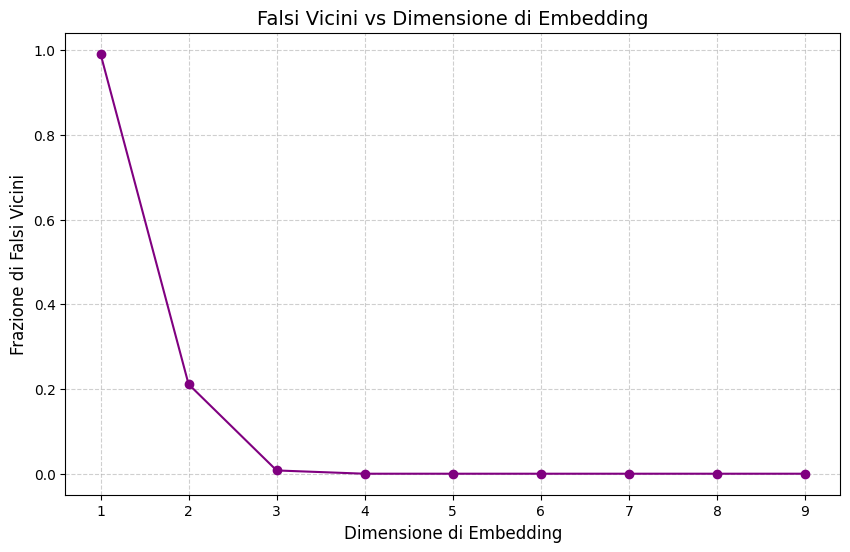

In [10]:
# Parametri
embedding_dimensions = range(1, 10)  # Dimensioni di embedding da analizzare
delay = 15  # Ritardo temporale
threshold = 10  # Soglia per definire i falsi vicini

# Esegui il calcolo della frazione di falsi vicini per i tuoi dati
false_neighbors_fractions = [
    false_nearest_neighbors(z2, delay, embedding_dimension=d, threshold=threshold)
    for d in embedding_dimensions
]

# Filtra eventuali valori None (se i dati sono insufficienti)
false_neighbors_fractions = [fnn for fnn in false_neighbors_fractions if fnn is not None]

# Grafico
plt.figure(figsize=(10, 6))
plt.plot(embedding_dimensions[:len(false_neighbors_fractions)], false_neighbors_fractions, marker='o', color='purple')
plt.xlabel('Dimensione di Embedding', fontsize=12)
plt.ylabel('Frazione di Falsi Vicini', fontsize=12)
plt.title('Falsi Vicini vs Dimensione di Embedding', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

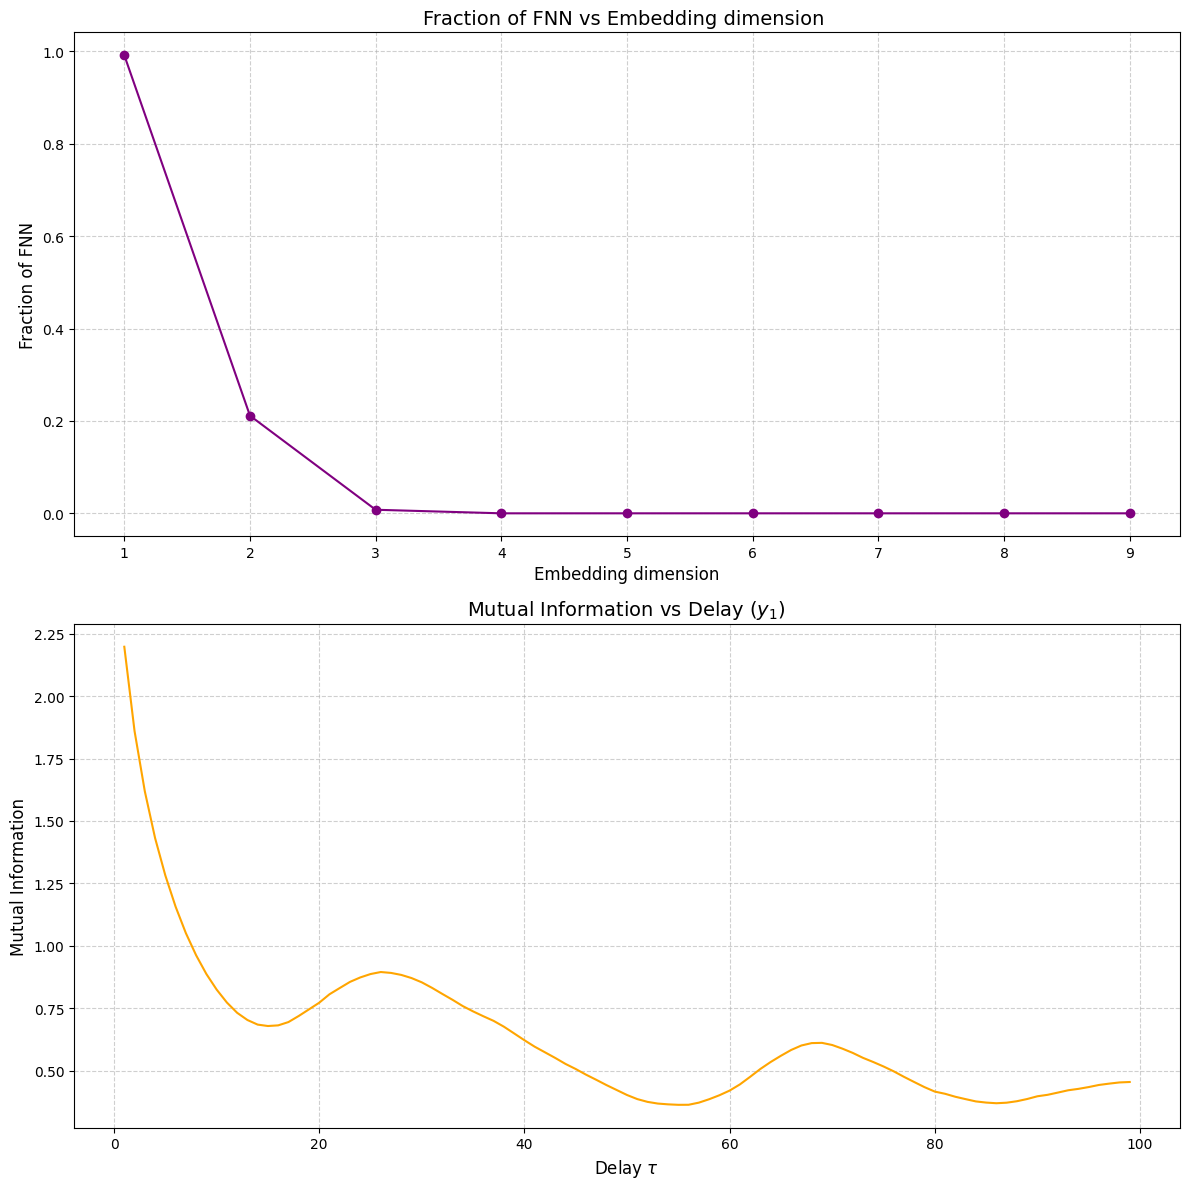

In [19]:
fig, axs = plt.subplots(2, 1, figsize=(12, 12))

# Plot for False Nearest Neighbors
axs[0].plot(embedding_dimensions[:len(false_neighbors_fractions)], false_neighbors_fractions, marker='o', color='purple')
axs[0].set_xlabel('Embedding dimension', fontsize=12)
axs[0].set_ylabel('Fraction of FNN', fontsize=12)
axs[0].set_title('Fraction of FNN vs Embedding dimension ', fontsize=14)
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot for datDelayInformation_2
axs[1].plot(range(1, range_f), datDelayInformation_2, color='orange')
axs[1].set_xlabel(r'Delay $\tau$', fontsize=12)
axs[1].set_ylabel('Mutual Information', fontsize=12)
axs[1].set_title(r'Mutual Information vs Delay ($y_1$) ', fontsize=14)
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Pseudo-inverse shape (rxd):  (20, 30)
Projected Hankel shape(rx n_sample):  (20, 9913)
Decompressed Hankel shape:  (30, 9913)
Difference between original and decompressed Hankel (Inverse MAtrix):  0.007463583592928662


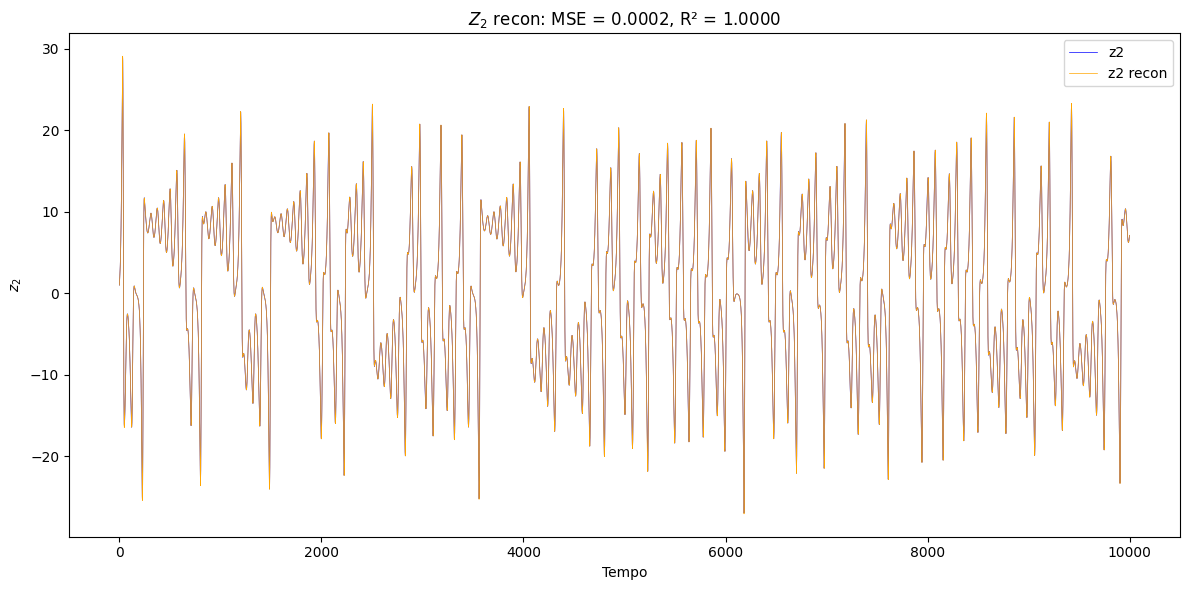

In [12]:
from numpy.linalg import pinv

# Original Hankel matrix
original_input_H1 = simulation.H1 #This is not modified by normalization

# Denormalization check
after = denormalize_columns(simulation.projected_H1, simulation.min_h1, simulation.max_h1)

# Calcola la pseudo-inversa di P
P_pseudo_inverse = pinv(simulation.P)

print("Pseudo-inverse shape (rxd): ", P_pseudo_inverse.shape)
print("Projected Hankel shape(rx n_sample): ", after.shape)

decompr_H1 = np.dot(after.T,P_pseudo_inverse)
decompr_H1 = decompr_H1.T
print("Decompressed Hankel shape: ", decompr_H1.shape)

# Test difference between original and decompressed Hankel
diffDeco = np.mean(np.abs(original_input_H1 - decompr_H1))
print("Difference between original and decompressed Hankel (Inverse MAtrix): ", diffDeco)

decompressed_signal = reconstruct_signal_from_embedding(decompr_H1.T,simulation.embedding_dim, simulation.tau)
original_signal = reconstruct_signal_from_embedding(original_input_H1.T,simulation.embedding_dim, simulation.tau)

# Calculate MSE and R²
mse1 = np.mean((original_signal - decompressed_signal) ** 2)
r2_1 = 1 - np.sum((original_signal - decompressed_signal) ** 2) / np.sum((original_signal - np.mean(original_signal)) ** 2)

# Plot dei segnali
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(original_signal, label="z2", color='blue', lw=0.5)
ax.plot(decompressed_signal, label="z2 recon", color='orange', lw=0.5)
ax.legend()
ax.set_title(r"$Z_2$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse1, r2_1))
ax.set_xlabel("Tempo")
ax.set_ylabel("$z_2$")

plt.tight_layout()
plt.show()
